<a href="https://colab.research.google.com/github/harishmuh/Computer_Vision_study/blob/main/Yolov3_static_images.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Object detection on static images with YOLO**

## **Introduction**

This tutorial provides a step-by-step guide to performing object detection on static images using the YOLOv3 (You Only Look Once) model. We will cover the entire process, from setting up the environment (in Google colab) and downloading necessary model files (weights and configuration) to preprocessing images, running inferences, and visualizing the detected objects with bounding boxes and class labels. The tutorial aims to demonstrate the practical application of a pre-trained YOLOv3 model for identifying multiple objects within an image.

**Initial setup**

In [1]:
# Importing libraries
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import urllib.request
import numpy as np
from google.colab.patches import cv2_imshow

We will attach the first input image

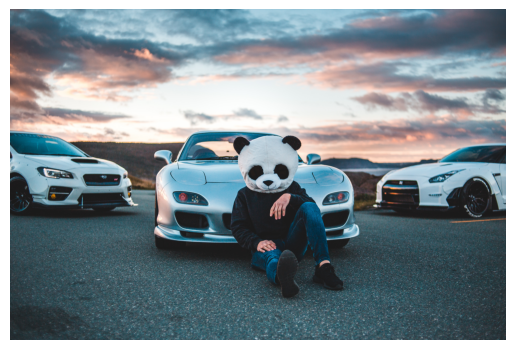

In [46]:
# Attaching the input image

# Image link
url = 'https://github.com/harishmuh/Deep-Learning_study/blob/main/data/DeepCV/person-car.jpg?raw=true'

# Download and open the image
with urllib.request.urlopen(url) as f:
    input_img = Image.open(f)

# Convert PIL Image to NumPy array for OpenCV compatibility
input_img = np.array(input_img)

# Displaying the original image
plt.axis('off')
plt.imshow(input_img, cmap='gray')
plt.show()

**Downloading starter files**

Now we need to download, starter files that include
* coco_classes.txt: Contains list of 80 classes in MS COCO (object detection model with data from Microsoft Common Objects in Context)
* yolov3.weights: contains model or network parameters that have been trained using MS COCO data
* yolov3.cfg: contains network architecture and YOLO parameters for model training and object detection

In [3]:
# Downloading starter files for YOLO V3 object detection

# Clean up existing files to ensure fresh download
!rm -f coco.names coco_classes.txt yolov3.weights yolov3.weights.1 yolov3.cfg yolov3.cfg.1 'view?usp=drive_link*' '1Qc7wbE2yZWZ4LmM4vk8ZtuaL48gTCKqQ?usp=drive_link'

# Downloading Label:coco.names (will be renamed to coco_classes.txt)
!wget https://raw.githubusercontent.com/pjreddie/darknet/master/data/coco.names

# Downloading weights
!wget https://pjreddie.com/media/files/yolov3.weights

# Downloading cfg
!wget https://raw.githubusercontent.com/pjreddie/darknet/master/cfg/yolov3.cfg

--2026-04-16 04:55:53--  https://raw.githubusercontent.com/pjreddie/darknet/master/data/coco.names
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 625 [text/plain]
Saving to: ‘coco.names’

coco.names          100%[===================>]     625  --.-KB/s    in 0s      

2026-04-16 04:55:53 (22.2 MB/s) - ‘coco.names’ saved [625/625]

--2026-04-16 04:55:53--  https://pjreddie.com/media/files/yolov3.weights
Resolving pjreddie.com (pjreddie.com)... 104.21.88.156, 172.67.185.199, 2606:4700:3037::6815:589c, ...
Connecting to pjreddie.com (pjreddie.com)|104.21.88.156|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://data.pjreddie.com/files/yolov3.weights [following]
--2026-04-16 04:55:53--  https://data.pjreddie.com/f

In [4]:
# Cleaning and reformatting the downloaded starter files

import os

# Rename coco.names to coco_classes.txt for consistency
# This assumes coco.names was just downloaded in the previous cell
if os.path.exists('coco.names'):
    os.rename('coco.names', 'coco_classes.txt')

# Handle cases where wget created .1 files if original files already existed
# Rename them to their base names so they can be loaded correctly
if os.path.exists('yolov3.weights.1'):
    # Remove the old yolov3.weights if it exists before renaming
    if os.path.exists('yolov3.weights'):
        os.remove('yolov3.weights')
    os.rename('yolov3.weights.1', 'yolov3.weights')

if os.path.exists('yolov3.cfg.1'):
    # Remove the old yolov3.cfg if it exists before renaming
    if os.path.exists('yolov3.cfg'):
        os.remove('yolov3.cfg')
    os.rename('yolov3.cfg.1', 'yolov3.cfg')

# Verify that the files have been downloaded and are correctly named
!ls -lh

total 237M
-rw-r--r-- 1 root root  625 Apr 16 04:55 coco_classes.txt
drwxr-xr-x 1 root root 4.0K Apr  2 13:31 sample_data
-rw-r--r-- 1 root root 8.2K Apr 16 04:55 yolov3.cfg
-rw-r--r-- 1 root root 237M Apr 21  2025 yolov3.weights


In [5]:
# Clean up existing files to avoid conflicts
!rm -f coco.names coco_classes.txt yolov3.weights yolov3.weights.1 yolov3.cfg yolov3.cfg.1 'view?usp=drive_link*' '1Qc7wbE2yZWZ4LmM4vk8ZtuaL48gTCKqQ?usp=drive_link'

# Downloading starter files again with correct URLs
# Downloading Label:coco.names (will be renamed to coco_classes.txt)
!wget https://raw.githubusercontent.com/pjreddie/darknet/master/data/coco.names

# Downloading weights
!wget https://pjreddie.com/media/files/yolov3.weights

# Downloading cfg
!wget https://raw.githubusercontent.com/pjreddie/darknet/master/cfg/yolov3.cfg

# Rename coco.names to coco_classes.txt for consistency
os.rename('coco.names', 'coco_classes.txt')

# Verify that the files have been downloaded and are correctly named
!ls -lh

--2026-04-16 04:55:57--  https://raw.githubusercontent.com/pjreddie/darknet/master/data/coco.names
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 625 [text/plain]
Saving to: ‘coco.names’

coco.names          100%[===================>]     625  --.-KB/s    in 0s      

2026-04-16 04:55:57 (11.4 MB/s) - ‘coco.names’ saved [625/625]

--2026-04-16 04:55:57--  https://pjreddie.com/media/files/yolov3.weights
Resolving pjreddie.com (pjreddie.com)... 104.21.88.156, 172.67.185.199, 2606:4700:3037::6815:589c, ...
Connecting to pjreddie.com (pjreddie.com)|104.21.88.156|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://data.pjreddie.com/files/yolov3.weights [following]
--2026-04-16 04:55:57--  https://data.pjreddie.com/f

In [6]:
# Converting images into required images
yolo_input = cv2.dnn.blobFromImage(image=input_img,
                                   scalefactor=1/255.0, # Pixel normalization
                                   size=(416,416),      # Resizing into required size
                                   swapRB=True)         # Swab channels

print(yolo_input.shape)

(1, 3, 416, 416)


In [7]:
weights = 'yolov3.weights'
cfg = 'yolov3.cfg'
net = cv2.dnn.readNet(weights, cfg)

In [8]:
layer_names = net.getLayerNames()

for i in layer_names[:10]:
    layer = net.getLayer(i)
    print(f"{layer.name} : {layer.type}")

conv_0 : Convolution
bn_0 : BatchNorm
leaky_1 : ReLU
conv_1 : Convolution
bn_1 : BatchNorm
leaky_2 : ReLU
conv_2 : Convolution
bn_2 : BatchNorm
leaky_3 : ReLU
conv_3 : Convolution


In [9]:
output_layers = [layer_names[i-1] for i in net.getUnconnectedOutLayers()]
print(f"{output_layers}")

['yolo_82', 'yolo_94', 'yolo_106']


In [10]:
net.setInput(yolo_input)
pred = net.forward(output_layers)

In [11]:
n_out = str(len(pred))        #number of components in pred
n_bb_out1 = str(len(pred[0])) #number of bounding boxes in output 1
n_bb_out2 = str(len(pred[1])) #number of bounding boxes in output 2
n_bb_out3 = str(len(pred[2])) #number of bounding boxes in output 3

out = f'There are {n_out} outputs with {n_bb_out1}, {n_bb_out2}, and {n_bb_out3} bounding boxes each'
print(out)

There are 3 outputs with 507, 2028, and 8112 bounding boxes each


In [12]:
bbt_list = []
maxclass_list = []
maxboxes_list = []

In [13]:
height, width, channels = input_img.shape #variable unpacking

In [14]:
# Loop for each output
for output in pred:

# Loop for each bounding box in each output
  for bounding_box in output:

    classes = bounding_box[5:] #prob value of 80 classes
    maxclass_idx = np.argmax(classes) #idx with the highest value
    bbt = classes[maxclass_idx] #highest value

    #1 Convert center point coordinates and box size
    center_x_img = int(bounding_box[0] * width)
    center_y_img = int(bounding_box[1] * height)
    w_img = int(bounding_box[2] * width)
    h_img = int(bounding_box[3] * height)

    #2 Calculate the coordinates of the top-left corner of the bounding box
    x_img = int(center_x_img - w_img / 2)
    y_img = int(center_y_img - h_img / 2)

    #3 Save the processing results
    maxboxes_list.append([x_img, y_img, w_img, h_img])
    bbt_list.append(float(bbt))
    maxclass_list.append(maxclass_idx)

In [15]:
indexes = cv2.dnn.NMSBoxes(bboxes=maxboxes_list,
                           scores=bbt_list,
                           score_threshold=0.6, # Filter I
                           nms_threshold=0.5)   # Filter II
print(indexes)

[237 267 334]


In [16]:
# Displaying list of class names
cocofile = open('coco_classes.txt', 'r')
lines = cocofile.readlines()
class_list = []
for line in lines:
   class_list.append(line.strip())

print(class_list)

['person', 'bicycle', 'car', 'motorbike', 'aeroplane', 'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'sofa', 'pottedplant', 'bed', 'diningtable', 'toilet', 'tvmonitor', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush']


In [47]:
# Setting output image for detection
# So, we don't change the input image
output_img = input_img.copy()


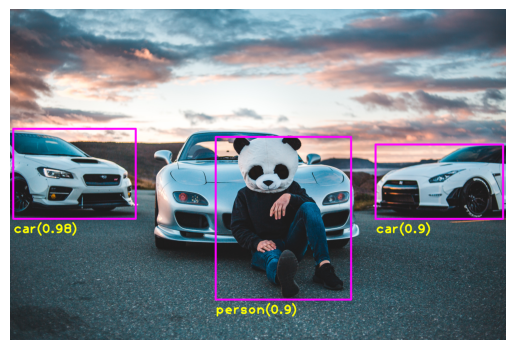

In [48]:
# Implementing bounding box

for i in indexes:

    x, y, w, h = maxboxes_list[i]	#variable unpacking

    class_names = class_list[maxclass_list[i]]
    prob_values = str(np.round(bbt_list[i],2))
    label = class_names + '(' + prob_values + ')'  # label

    # Adding bounding box
    cv2.rectangle(img=output_img,
                  pt1=(x, y),
                  pt2=(x + w, y + h),
                  color=(255,0,255),
                  thickness=20)

    # Adding labels
    cv2.putText(img=output_img,
                text=label,
                org=(x, y + h + 150),
                fontFace=cv2.FONT_HERSHEY_PLAIN,
                fontScale=9,
                color=(255,255,0),
                thickness=15)

plt.axis('off')
#output_img = cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB)
plt.imshow(output_img)
plt.show()


Now, we will generate functions to implement YOLO more practically

## **Object Detection Function**

We will now create a function `yolo_object_detection` that takes an image (NumPy array) as input, performs object detection using the pre-trained YOLOv3 model, and returns the image with bounding boxes and class labels drawn on it. This function integrates the preprocessing, inference, and post-processing steps implemented previously.

In [35]:
# Defining YOLO object detection function
def yolo_object_detection(image_np_array, net, class_list, score_threshold=0.6, nms_threshold=0.5, box_thickness=20, text_font_scale=15, text_thickness=15):
    """
    Performs object detection on an image using a pre-trained YOLOv3 model.

    Args:
        image_np_array (numpy.ndarray): The input image as a NumPy array (H, W, C).
        net (cv2.dnn.Net): The loaded YOLOv3 network.
        class_list (list): A list of class names.
        score_threshold (float): Confidence threshold to filter weak detections.
        nms_threshold (float): Non-maximum suppression threshold.
        box_thickness (int): Thickness of the bounding box lines.
        text_font_scale (float): Font scale for the detection text.
        text_thickness (int): Thickness of the detection text.

    Returns:
        numpy.ndarray: The image with detected objects, bounding boxes, and labels drawn.
    """
    processed_image = image_np_array.copy()
    height, width, channels = processed_image.shape

    # 1. Image preprocessing for YOLO
    yolo_input = cv2.dnn.blobFromImage(
        image=processed_image,
        scalefactor=1 / 255.0,  # Pixel normalization
        size=(416, 416),        # Resizing into required size
        swapRB=True             # Swap channels (BGR to RGB, as OpenCV loads BGR by default)
    )

    # Get output layer names
    output_layers = [net.getLayerNames()[i - 1] for i in net.getUnconnectedOutLayers()]

    # 2. Forward pass through the network
    net.setInput(yolo_input)
    predictions = net.forward(output_layers)

    bbt_list = []
    maxclass_list = []
    maxboxes_list = []

    # 3. Process predictions
    for output in predictions:
        for bounding_box in output:
            classes = bounding_box[5:]
            maxclass_idx = np.argmax(classes)
            bbt = classes[maxclass_idx]

            if bbt > score_threshold: # Apply confidence filter
                center_x_img = int(bounding_box[0] * width)
                center_y_img = int(bounding_box[1] * height)
                w_img = int(bounding_box[2] * width)
                h_img = int(bounding_box[3] * height)

                x_img = int(center_x_img - w_img / 2)
                y_img = int(center_y_img - h_img / 2)

                maxboxes_list.append([x_img, y_img, w_img, h_img])
                bbt_list.append(float(bbt))
                maxclass_list.append(maxclass_idx)

    # 4. Apply Non-Maximum Suppression (NMS)
    indexes = cv2.dnn.NMSBoxes(
        bboxes=maxboxes_list,
        scores=bbt_list,
        score_threshold=score_threshold, # Filter I (already applied above, but NMSBoxes expects it)
        nms_threshold=nms_threshold      # Filter II
    )

    # Ensure indexes is a flat array if it's not empty
    if len(indexes) > 0:
        indexes = indexes.flatten()

    # 5. Draw bounding boxes and labels on the image
    for i in indexes:
        x, y, w, h = maxboxes_list[i]

        class_name = class_list[maxclass_list[i]]
        prob_value = str(np.round(bbt_list[i], 2))
        label = f"{class_name}({prob_value})"

        # Bounding box color and thickness
        cv2.rectangle(
            img=processed_image,
            pt1=(x, y),
            pt2=(x + w, y + h),
            color=(255, 0, 255), # Magenta
            thickness=box_thickness
        )

        # Label color, font and thickness
        cv2.putText(
            img=processed_image,
            text=label,
            org=(x, y + h + int(text_font_scale * 15)), # Position below the box, adjusted by font scale
            fontFace=cv2.FONT_HERSHEY_PLAIN,
            fontScale=text_font_scale,
            color=(255, 255, 0), # Yellow
            thickness=text_thickness
        )

    return processed_image

Now let's test our new function with the `input_img` we loaded earlier.

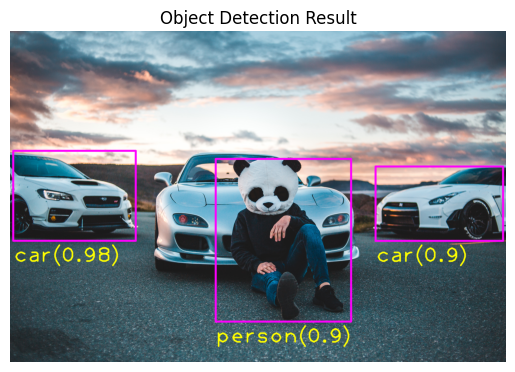

In [49]:
# Assuming 'net' and 'class_list' are already loaded from previous cells
# Use the function to perform object detection on the original input image
output_image_with_detections = yolo_object_detection(input_img, net, class_list)

# Display the output image
plt.axis('off')
plt.imshow(output_image_with_detections)
plt.title('Object Detection Result')
plt.show()

Now, we will use new input image

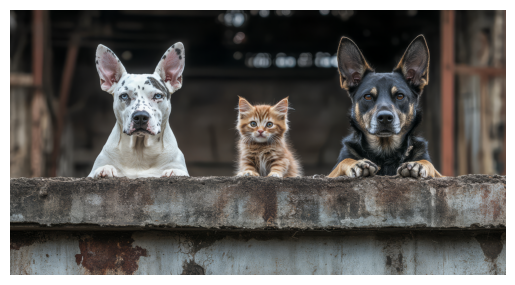

In [42]:
# Attaching the input image

# Image link
url_1 = 'https://github.com/harishmuh/Computer_Vision_study/blob/main/data/images/dog_cat.PNG?raw=true'

# Download and open the image
with urllib.request.urlopen(url_1) as f:
    input_img_1 = Image.open(f)

# Convert PIL Image to NumPy array for OpenCV compatibility, ensuring it's 3-channel RGB
input_img_1 = np.array(input_img_1.convert('RGB'))

# Displaying the original image
plt.axis('off')
plt.imshow(input_img_1, cmap='gray')
plt.show()

Implementing to the new image

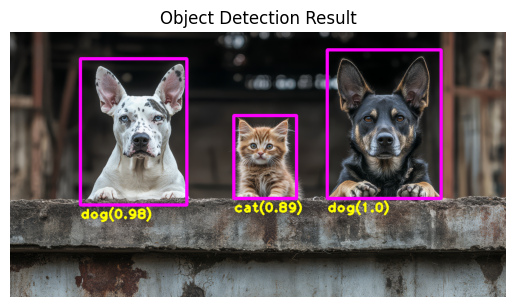

In [44]:
# Use the function to perform object detection on the original input image with adjusted parameters
output_image_with_detections_1 = yolo_object_detection(
    input_img_1,
    net,
    class_list,
    box_thickness=5,       # Smaller bounding box thickness
    text_font_scale=2,     # Smaller font scale
    text_thickness=3       # Smaller text thickness
)

# Display the output image
plt.axis('off')
plt.imshow(output_image_with_detections_1)
plt.title('Object Detection Result')
plt.show()

## **Conclusion**

In this tutorial, we successfully implemented object detection on static images using the pre-trained YOLOv3 model. We covered the essential steps, including:

1.  **Environment Setup**: Importing necessary libraries and handling file downloads.
2.  **Image Preprocessing**: Preparing input images for the YOLO model.
3.  **Model Inference**: Loading the YOLOv3 model and performing predictions.
4.  **Post-processing**: Applying non-maximum suppression (NMS) to filter redundant bounding boxes.
5.  **Visualization**: Drawing bounding boxes and class labels on the detected objects.
6.  **Function Encapsulation**: Creating a reusable function for streamlined object detection.

By following these steps, we were able to accurately identify and localize objects such as persons, cars, dogs, and cats in various images. This tutorial demonstrates the practical application of deep learning for computer vision tasks and provides a solid foundation for further exploration into object detection.